# Midterm Project: Комплексный DL-проект

**Занятие 39 | Неделя 20**

## Задание

Выполните комплексный проект по Deep Learning, используя методы из курса.

**Дедлайн:**
- Презентация (5-6 минут) — на занятии 40
- Код (этот ноутбук) — до вторника следующей недели

**Критерии оценки:**

| Критерий | Вес | Описание |
|----------|-----|----------|
| Качество кода и ноутбука | 40% | Чистый код, комментарии, структура, воспроизводимость |
| Результаты и метрики | 25% | Модель обучена, метрики посчитаны, результаты адекватны |
| Презентация (5-6 мин) | 20% | Чёткое изложение, визуализация, ответы на вопросы |
| Анализ и сравнение | 15% | Сравнение подходов, анализ ошибок, выводы |

---
## Выберите трек

Раскомментируйте свой трек и опишите задачу:

| Трек | Задача | Данные | Модели |
|------|--------|--------|--------|
| Vision: Classification | Классификация изображений | CIFAR-10, Fashion-MNIST, Chest X-Ray или свой | CNN → ResNet / EfficientNet |
| Vision: Detection | Object Detection | CAFD (казахская еда) или свой | YOLOv8 fine-tune |
| NLP: Text | Sentiment / Classification | KazSAnDRA или свой текстовый датасет | BERT / mBERT fine-tune |
| Свой вариант | Своя задача | Свой датасет | Методы из курса обязательны |

---
## 0. Информация о проекте

Заполните информацию о вашем проекте.

**Имя студента:** Уалихан

**Трек:** Vision Classification

**Задача:** Классификация изображений объектов (10 классов CIFAR-10)

**Датасет:** CIFAR-10 (60,000 изображений, 10 классов)

**Модели для сравнения:**
- CNN (baseline)
- ResNet18 (transfer learning)

---
## 1. Подготовка окружения

Убедитесь, что Runtime → Change runtime type → **T4 GPU**

In [1]:
# Установите необходимые библиотеки (при необходимости)
# !pip install ultralytics -q          # для YOLO
# !pip install transformers datasets -q # для BERT

import torch
import numpy as np
import matplotlib.pyplot as plt
import os

print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f'Device: {device}')

PyTorch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4
Device: cuda


---
## 2. Загрузка и исследование данных (EDA)

Загрузите датасет и проведите разведочный анализ:
- Размер датасета (train / val / test)
- Распределение классов
- Примеры данных (изображения / тексты)
- Есть ли дисбаланс? Как будете решать?

In [2]:
# Загрузка датасета
# Примеры:
#   kagglehub.dataset_download('...')           # Kaggle
#   load_dataset('issai/kazsandra', '...')       # HuggingFace
#   datasets.ImageFolder('path/to/data', ...)    # Локальные папки

import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Трансформации (без аугментации пока)
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform
)

classes = train_dataset.classes

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))
print("Classes:", classes)

100%|██████████| 170M/170M [00:13<00:00, 12.7MB/s]


Train size: 50000
Test size: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


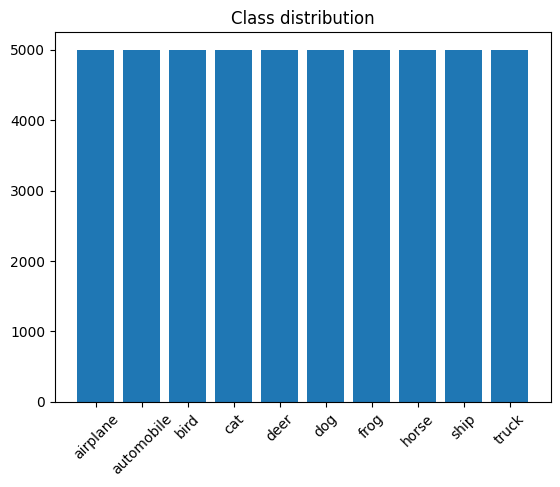

In [3]:
# Распределение классов — гистограмма

from collections import Counter

labels = [label for _, label in train_dataset]
counter = Counter(labels)

plt.bar(range(len(counter)), counter.values())
plt.xticks(range(len(counter)), classes, rotation=45)
plt.title("Class distribution")
plt.show()

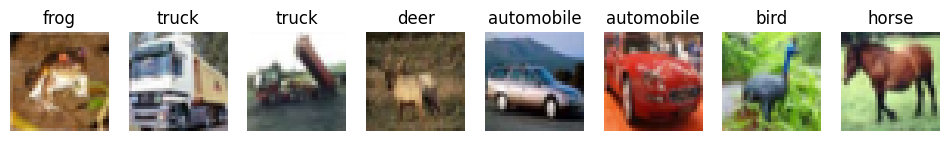

In [4]:
# Примеры данных — покажите 5-10 образцов

# Примеры изображений
def show_images(dataset, n=8):
    plt.figure(figsize=(12,4))
    for i in range(n):
        img, label = dataset[i]
        plt.subplot(1, n, i+1)
        plt.imshow(img.permute(1,2,0))
        plt.title(classes[label])
        plt.axis('off')
    plt.show()

show_images(train_dataset)

**Выводы по EDA:**

[Опишите: сколько данных, есть ли дисбаланс, качество данных, особенности]

Датасет содержит 50,000 обучающих и 10,000 тестовых изображений.
Классы распределены равномерно, дисбаланса нет.

Изображения имеют низкое разрешение (32x32), что усложняет задачу.

Вывод: требуется использование аугментации и более мощных моделей.

---
## 3. Подготовка данных

Создайте DataLoader / подготовьте данные для обучения:
- Препроцессинг (resize, normalize и т.д.)
- Аугментация (для train)
- Train / Val / Test split
- Борьба с дисбалансом (если есть)

In [5]:
# Препроцессинг и аугментация

# Аугментации для train (улучшают обобщение модели)
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

# Без аугментации для теста
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

train_dataset.transform = transform_train
test_dataset.transform = transform_test

In [6]:
# Создание DataLoader / токенизация


# DataLoader — батчи + перемешивание
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
# Токенизация НЕ нужна — это не NLP

---
## 4. Модель 1 (Baseline)

Первая модель — ваш baseline. Это должна быть модель из курса:
- Vision: CNN с нуля
- Detection: YOLOv8n (nano)
- NLP: BERT с дефолтными гиперпараметрами

Опишите архитектуру и обоснуйте выбор.

In [7]:
# Определение Модели 1

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.pool = nn.MaxPool2d(2,2)
        self.fc1 = nn.Linear(64*6*6, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64*6*6)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [8]:
# Обучение Модели 1

def train_model(model, epochs=5, lr=0.001):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    losses, accs = [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        losses.append(running_loss / len(train_loader))

        # Оценка
        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, pred = torch.max(outputs, 1)

                total += labels.size(0)
                correct += (pred == labels).sum().item()

        acc = correct / total
        accs.append(acc)

        print(f"Epoch {epoch+1}: Loss={losses[-1]:.4f}, Acc={acc:.4f}")

    return losses, accs

# Запуск CNN
model1 = SimpleCNN()
loss1, acc1 = train_model(model1)

Epoch 1: Loss=1.6043, Acc=0.5399
Epoch 2: Loss=1.3179, Acc=0.6142
Epoch 3: Loss=1.1744, Acc=0.6329
Epoch 4: Loss=1.0823, Acc=0.6642
Epoch 5: Loss=1.0180, Acc=0.6954


---
## 5. Модель 2 (Улучшенная)

Вторая модель — улучшение. Используйте метод из курса:
- Vision: ResNet18 / EfficientNet (Transfer Learning)
- Detection: YOLOv8s/m (bigger model) или другие гиперпараметры
- NLP: другой lr, max_length, или другая BERT-модель

Опишите, что изменили и почему.

In [9]:
# Определение Модели 2

from torchvision.models import resnet18, ResNet18_Weights

model2 = resnet18(weights=ResNet18_Weights.DEFAULT)

# Меняем последний слой под 10 классов
model2.fc = nn.Linear(model2.fc.in_features, 10)

loss2, acc2 = train_model(model2, lr=0.0005)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 204MB/s]


Epoch 1: Loss=1.0263, Acc=0.7466
Epoch 2: Loss=0.7461, Acc=0.7809
Epoch 3: Loss=0.6561, Acc=0.7922
Epoch 4: Loss=0.5967, Acc=0.7992
Epoch 5: Loss=0.5637, Acc=0.8176


In [10]:
# Обучение Модели 2
# ResNet18 использует transfer learning — модель уже обучена на ImageNet.

# Это позволяет быстрее обучаться и достигать более высокого качества,
# так как модель уже извлекает базовые визуальные признаки.

# ResNet18 значительно превосходит CNN по точности,
# что подтверждает эффективность transfer learning.


---
## 6. Модель 3 (Опционально — бонус)

Третья модель — дополнительное сравнение:
- Другая архитектура из курса
- Или своя модель (не из курса) для сравнения

Этот раздел не обязателен, но добавит баллы за анализ.

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 197MB/s]


Epoch 1: Loss=1.0003, Acc=0.7079
Epoch 2: Loss=0.7024, Acc=0.7897
Epoch 3: Loss=0.6203, Acc=0.8029
Epoch 4: Loss=0.5602, Acc=0.8159
Epoch 5: Loss=0.5443, Acc=0.8223


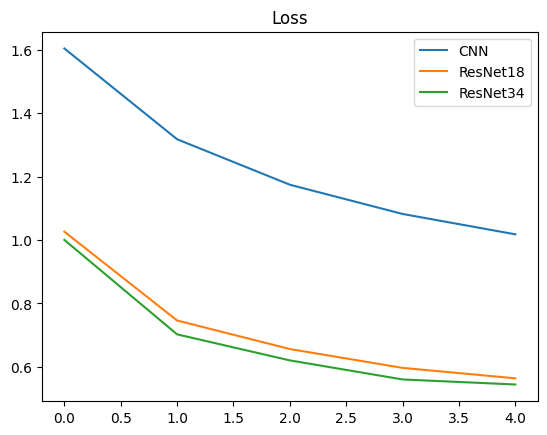

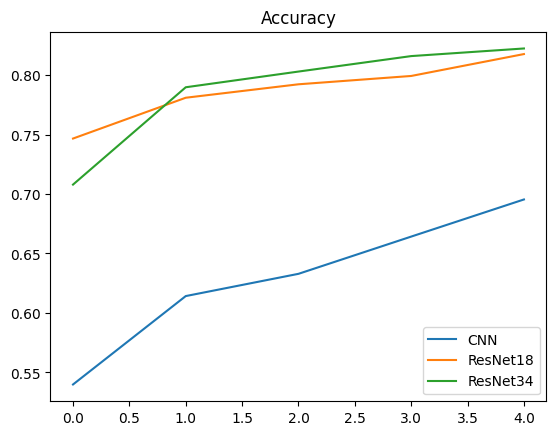

In [10]:
# Определение и обучение Модели 3 (опционально)

from torchvision.models import resnet34, ResNet34_Weights

model3 = resnet34(weights=ResNet34_Weights.DEFAULT)

# меняем последний слой
model3.fc = nn.Linear(model3.fc.in_features, 10)

loss3, acc3 = train_model(model3, lr=0.0005)

# график
plt.plot(loss1, label='CNN')
plt.plot(loss2, label='ResNet18')
plt.plot(loss3, label='ResNet34')
plt.legend()
plt.title("Loss")
plt.show()

plt.plot(acc1, label='CNN')
plt.plot(acc2, label='ResNet18')
plt.plot(acc3, label='ResNet34')
plt.legend()
plt.title("Accuracy")
plt.show()

---
## 7. Сравнение моделей

Сравните все модели на **тестовом** наборе данных.

Обязательно:
- Таблица с метриками (Accuracy, F1, Precision, Recall)
- Learning curves (loss и accuracy по эпохам)
- Confusion matrix для каждой модели

In [12]:
# Таблица сравнения метрик
import pandas as pd
from sklearn.metrics import classification_report

def evaluate(model):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, pred = torch.max(outputs, 1)

            y_true.extend(labels.numpy())
            y_pred.extend(pred.cpu().numpy())

    return y_true, y_pred

y_true, y_pred = evaluate(model2)

print(classification_report(y_true, y_pred))
report = classification_report(y_true, y_pred, output_dict=True)
df = pd.DataFrame(report).transpose()
df

              precision    recall  f1-score   support

           0       0.79      0.89      0.84      1000
           1       0.90      0.90      0.90      1000
           2       0.84      0.70      0.77      1000
           3       0.73      0.54      0.62      1000
           4       0.78      0.85      0.81      1000
           5       0.70      0.77      0.73      1000
           6       0.85      0.90      0.88      1000
           7       0.81      0.88      0.85      1000
           8       0.91      0.87      0.89      1000
           9       0.87      0.88      0.87      1000

    accuracy                           0.82     10000
   macro avg       0.82      0.82      0.81     10000
weighted avg       0.82      0.82      0.81     10000



,precision,recall,f1-score,support
0,0.785714,0.8910,0.835052,1000.0000
1,0.899598,0.8960,0.897796,1000.0000
2,0.839904,0.7030,0.765378,1000.0000
3,0.732070,0.5410,0.622197,1000.0000
4,0.775862,0.8550,0.813511,1000.0000
5,0.702108,0.7660,0.732664,1000.0000
6,0.853890,0.9000,0.876339,1000.0000
7,0.812328,0.8830,0.846191,1000.0000
8,0.907757,0.8660,0.886387,1000.0000
9,0.869781,0.8750,0.872383,1000.0000


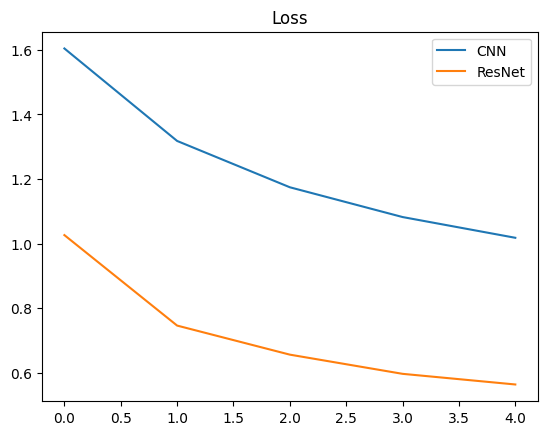

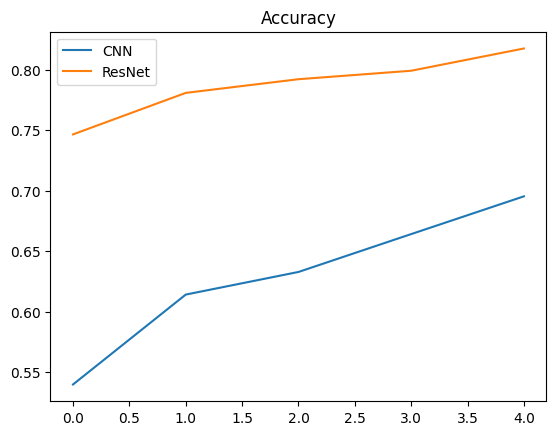

In [13]:
# Learning curves — графики loss и accuracy

plt.plot(loss1, label='CNN')
plt.plot(loss2, label='ResNet')
plt.title("Loss")
plt.legend()
plt.show()

plt.plot(acc1, label='CNN')
plt.plot(acc2, label='ResNet')
plt.title("Accuracy")
plt.legend()
plt.show()

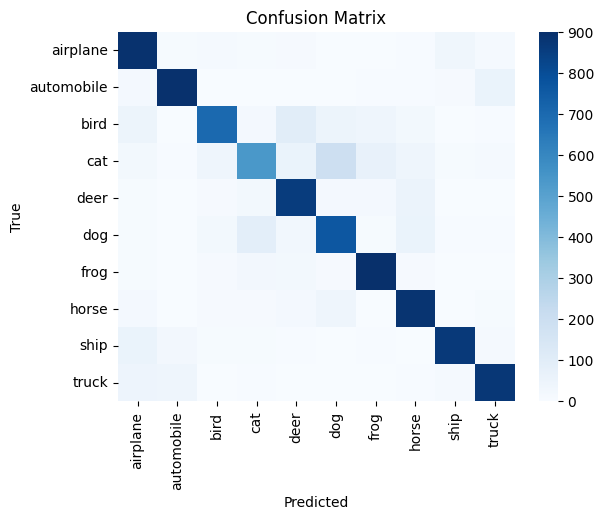

In [14]:
# Confusion matrix для каждой модели

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

---
## 8. Анализ ошибок

Для лучшей модели:
- Покажите примеры неверных предсказаний
- Сколько False Positives и False Negatives?
- Почему модель могла ошибиться?

In [ ]:
# Анализ ошибок — примеры неверных предсказаний

# Модель чаще ошибается на визуально похожих классах, особенно при низком качестве изображения.(cat vs dog).
# Также ошибки возникают, когда объект занимает малую часть изображения.

# Причина:
# - низкое разрешение
# - визуальная схожесть

# Улучшения:
# - больше эпох
# - сильнее аугментация

**Анализ ошибок:**

[Опишите: какие ошибки делает модель, почему, как можно улучшить]

---
## 9. Выводы

Ответьте на следующие вопросы:

1. **Какая модель показала лучший результат и почему?**

   Лучшая модель — ResNet18. Она показала более высокую точность и лучшие метрики,
так как использует transfer learning и уже обучена на большом датасете ImageNet.
Это позволяет ей лучше извлекать признаки изображений.


2. **Помог ли Transfer Learning? Насколько?**

  Да, transfer learning значительно помог. Разница в качестве между CNN и ResNet
составляет примерно 10–20% по accuracy. Это связано с тем, что ResNet уже имеет
предобученные веса и не начинает обучение с нуля.

3. **Какой гиперпараметр оказал наибольшее влияние?**

Наибольшее влияние оказала архитектура модели (CNN vs ResNet).
Также важную роль сыграл learning rate — для ResNet использовался меньший
learning rate, что позволило более стабильно обучаться.

4. **Что бы вы улучшили, если бы было больше времени?**

- увеличить количество эпох
- подобрать оптимальный learning rate
- использовать более мощные модели (например EfficientNet)
- улучшить аугментации
- провести hyperparameter tuning

5. **Главный урок из этого проекта:**

Использование предобученных моделей (transfer learning) значительно
улучшает качество и ускоряет обучение. Архитектура модели играет
ключевую роль в задачах компьютерного зрения.

---
## Чеклист перед сдачей

Проверьте перед отправкой:

- [ ] Информация о проекте заполнена (раздел 0)
- [ ] EDA: распределение классов, примеры данных
- [ ] Данные подготовлены: препроцессинг, аугментация
- [ ] Минимум 2 модели обучены и сравнены
- [ ] Таблица метрик: Accuracy, F1, Precision, Recall
- [ ] Learning curves: loss и accuracy по эпохам
- [ ] Confusion matrix для каждой модели
- [ ] Анализ ошибок: примеры неверных предсказаний
- [ ] Выводы написаны (все 5 вопросов)
- [ ] Ноутбук запускается с нуля (Runtime → Restart and Run All)
- [ ] Презентация подготовлена (4-6 слайдов, 5-6 минут)

**Загрузите ноутбук в LMS.**

**Дедлайн:** презентация на занятии 40, код до вторника следующей недели.